<a href="https://colab.research.google.com/github/mrivassnj-svg/HCC_ITAI_1371_SPR26/blob/main/Module_12_Lab_Ethics%2C_Fairness%2C_and_Bias_in_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 12 Lab - Ethics, Fairness, and Bias in ML

**Objective:** To understand how machine learning models can inherit and amplify societal biases, how to measure this bias using fairness metrics, and to think critically about the ethical implications of deploying ML systems.

**In this lab, you will train a model on a real-world dataset and audit it for fairness across different demographic groups.**

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

## Part 1: What is Algorithmic Bias?

**Concept:** Machine learning models learn from data. If the data reflects existing societal biases, the model will learn those biases. An "unbiased" algorithm trained on biased data will produce a biased model. This can lead to systems that are systematically unfair to certain groups of people.

**Sources of Bias:**
*   **Historical Bias:** The data reflects a world with historical injustices (e.g., past hiring data may show fewer women in leadership roles).
*   **Measurement Bias:** The way we collect or measure data is flawed (e.g., using arrest records as a proxy for crime, which can be influenced by policing patterns).
*   **Representation Bias:** The data underrepresents certain groups, so the model doesn't learn to perform well for them.

**Problem:** We will use the "Adult" dataset, which is used to predict whether an individual's income is greater than $50k/year. It contains sensitive attributes like `sex` and `race`, which we can use to audit our model for bias.

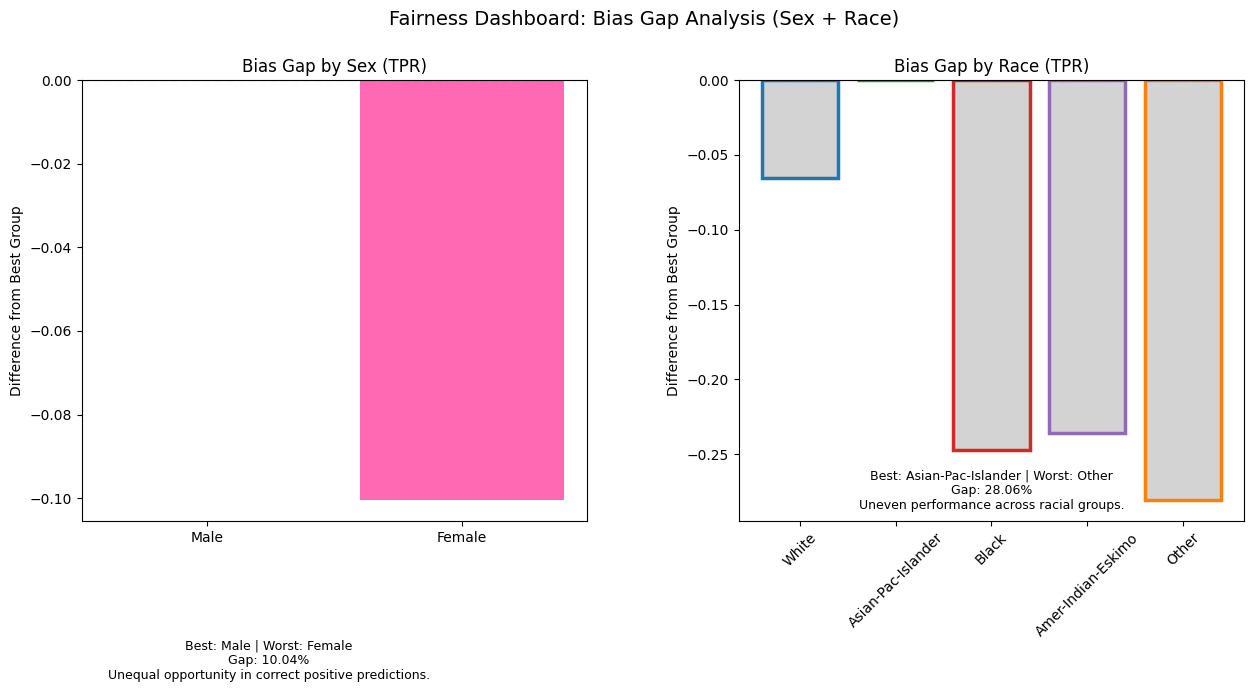

In [36]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

sex_df = sex_metrics.copy()

best_sex_value = sex_df['TPR'].max()
sex_df['Bias Gap'] = sex_df['TPR'] - best_sex_value

colors = ['hotpink' if str(v).lower() == 'female' else 'skyblue'
          for v in sex_df['sex']]

axes[0].bar(sex_df['sex'], sex_df['Bias Gap'], color=colors)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_title("Bias Gap by Sex (TPR)")
axes[0].set_ylabel("Difference from Best Group")

best_sex = sex_df.loc[sex_df['TPR'].idxmax(), 'sex']
worst_sex = sex_df.loc[sex_df['TPR'].idxmin(), 'sex']
sex_gap = sex_df['TPR'].max() - sex_df['TPR'].min()

fig.text(
    0.25, 0.02,
    f"Best: {best_sex} | Worst: {worst_sex}\nGap: {sex_gap:.2%}\n"
    "Unequal opportunity in correct positive predictions.",
    ha='center', va='bottom', fontsize=9
)


race_df = race_metrics.copy()

best_race_value = race_df['TPR'].max()
race_df['Bias Gap'] = race_df['TPR'] - best_race_value

edge_palette = {
    'White': '#1f77b4',
    'Black': '#d62728',
    'Asian-Pac-Islander': '#2ca02c',
    'Amer-Indian-Eskimo': '#9467bd',
    'Other': '#ff7f0e'
}

bars = axes[1].bar(race_df['race'], race_df['Bias Gap'], color='lightgray')

for bar, group in zip(bars, race_df['race']):
    bar.set_edgecolor(edge_palette.get(group, 'black'))
    bar.set_linewidth(2.5)

axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title("Bias Gap by Race (TPR)")
axes[1].set_ylabel("Difference from Best Group")
axes[1].tick_params(axis='x', rotation=45)

best_race = race_df.loc[race_df['TPR'].idxmax(), 'race']
worst_race = race_df.loc[race_df['TPR'].idxmin(), 'race']
race_gap = race_df['TPR'].max() - race_df['TPR'].min()

axes[1].text(
    0.5, 0.02,
    f"Best: {best_race} | Worst: {worst_race}\nGap: {race_gap:.2%}\n"
    "Uneven performance across racial groups.",
    ha='center', va='bottom', transform=axes[1].transAxes, fontsize=9
)


plt.suptitle("Fairness Dashboard: Bias Gap Analysis (Sex + Race)", fontsize=14)

plt.subplots_adjust(bottom=0.25, wspace=0.3)

plt.show()

## Part 2: Auditing the Model for Fairness

High overall accuracy can hide poor performance on specific subgroups. We need to audit the model by comparing its performance across sensitive attributes like `sex`.

**Concept: Group Fairness**
One common fairness goal is to ensure the model works equally well for different groups. We can measure this by calculating metrics for each group separately.

**Your Task:** Create a function to calculate accuracy for different subgroups and then use it to compare the model's performance for males and females.

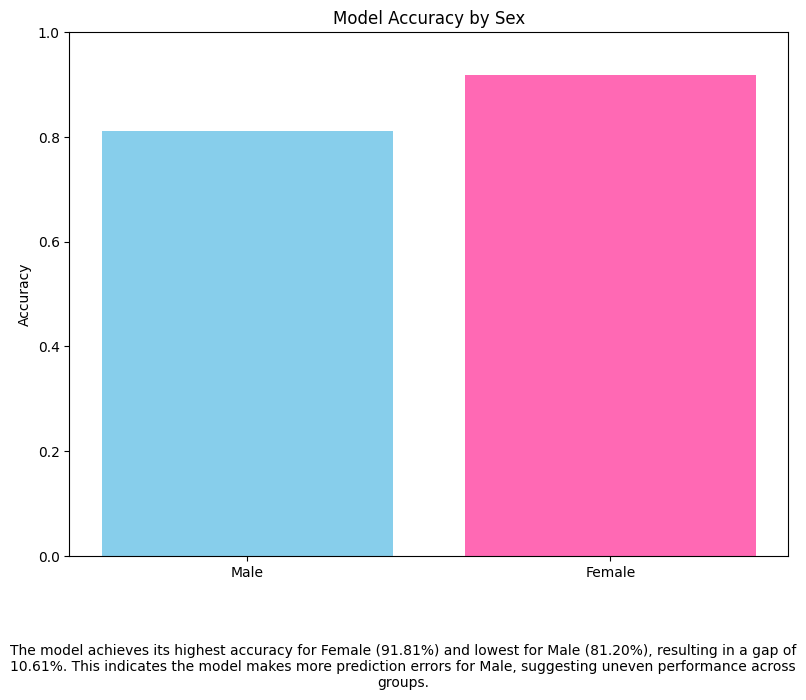

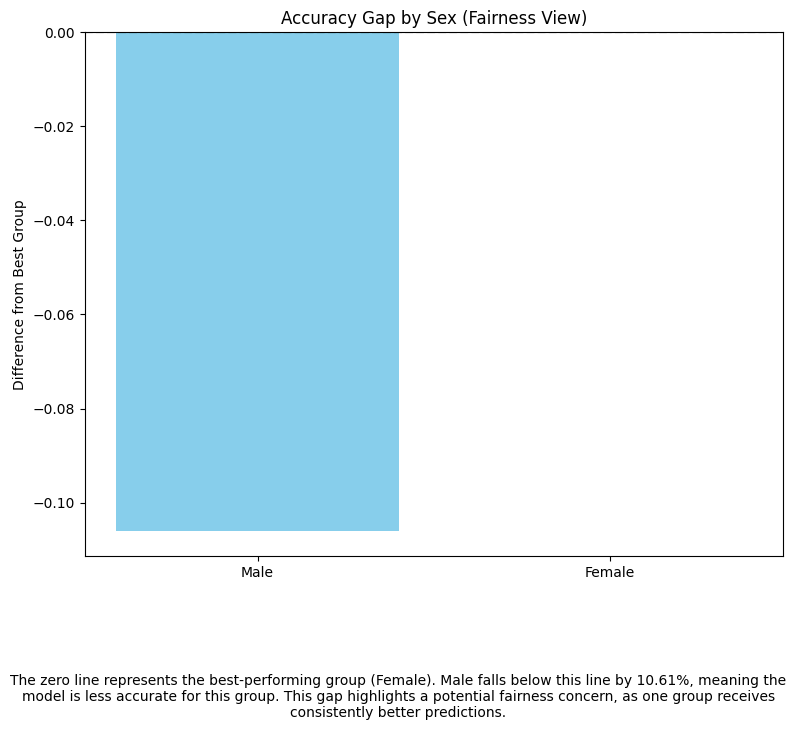

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
import pandas as pd

def get_subgroup_accuracy(model, X_test, y_test, subgroup_column, subgroup_value):
    mask = X_test[subgroup_column] == subgroup_value
    X_sub = X_test[mask]
    y_sub = y_test[mask]
    y_pred_sub = model.predict(X_sub)
    return accuracy_score(y_sub, y_pred_sub)

groups = X_test['sex'].unique()
accuracies = []

for group in groups:
    acc = get_subgroup_accuracy(model, X_test, y_test, 'sex', group)
    accuracies.append(acc)

subgroup_df = pd.DataFrame({
    'Group': groups,
    'Accuracy': accuracies
})

best_group = subgroup_df.loc[subgroup_df['Accuracy'].idxmax()]
worst_group = subgroup_df.loc[subgroup_df['Accuracy'].idxmin()]
gap = best_group['Accuracy'] - worst_group['Accuracy']

colors = ['hotpink' if g.lower() == 'female' else 'skyblue' for g in subgroup_df['Group']]

plt.figure(figsize=(8,6))
plt.bar(subgroup_df['Group'], subgroup_df['Accuracy'], color=colors)
plt.title("Model Accuracy by Sex")
plt.ylabel("Accuracy")
plt.ylim(0,1)

obs_text = (
    f"The model achieves its highest accuracy for {best_group['Group']} "
    f"({best_group['Accuracy']:.2%}) and lowest for {worst_group['Group']} "
    f"({worst_group['Accuracy']:.2%}), resulting in a gap of {gap:.2%}. "
    f"This indicates the model makes more prediction errors for {worst_group['Group']}, "
    f"suggesting uneven performance across groups."
)

plt.figtext(0.5, -0.15, obs_text, wrap=True, ha='center', fontsize=10)
plt.tight_layout()
plt.show()

subgroup_df['Gap from Best'] = subgroup_df['Accuracy'] - best_group['Accuracy']

plt.figure(figsize=(8,6))
plt.bar(subgroup_df['Group'], subgroup_df['Gap from Best'], color=colors)
plt.axhline(0, color='black', linestyle='--')
plt.title("Accuracy Gap by Sex (Fairness View)")
plt.ylabel("Difference from Best Group")

gap_text = (
    f"The zero line represents the best-performing group ({best_group['Group']}). "
    f"{worst_group['Group']} falls below this line by {gap:.2%}, meaning the model is less accurate for this group. "
    f"This gap highlights a potential fairness concern, as one group receives consistently better predictions."
)

plt.figtext(0.5, -0.2, gap_text, wrap=True, ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### Task 2: Deeper Dive with a Confusion Matrix

Accuracy alone doesn't tell the whole story. Let's look at the types of errors the model makes for each group.

**Your Task:** Calculate and compare the **False Positive Rate (FPR)** and **False Negative Rate (FNR)** for males and females.
*   **FPR:** `FP / (FP + TN)` - The percentage of people who did NOT have high income but were incorrectly predicted to have high income.
*   **FNR:** `FN / (FN + TP)` - The percentage of people who DID have high income but were incorrectly predicted to have low income.

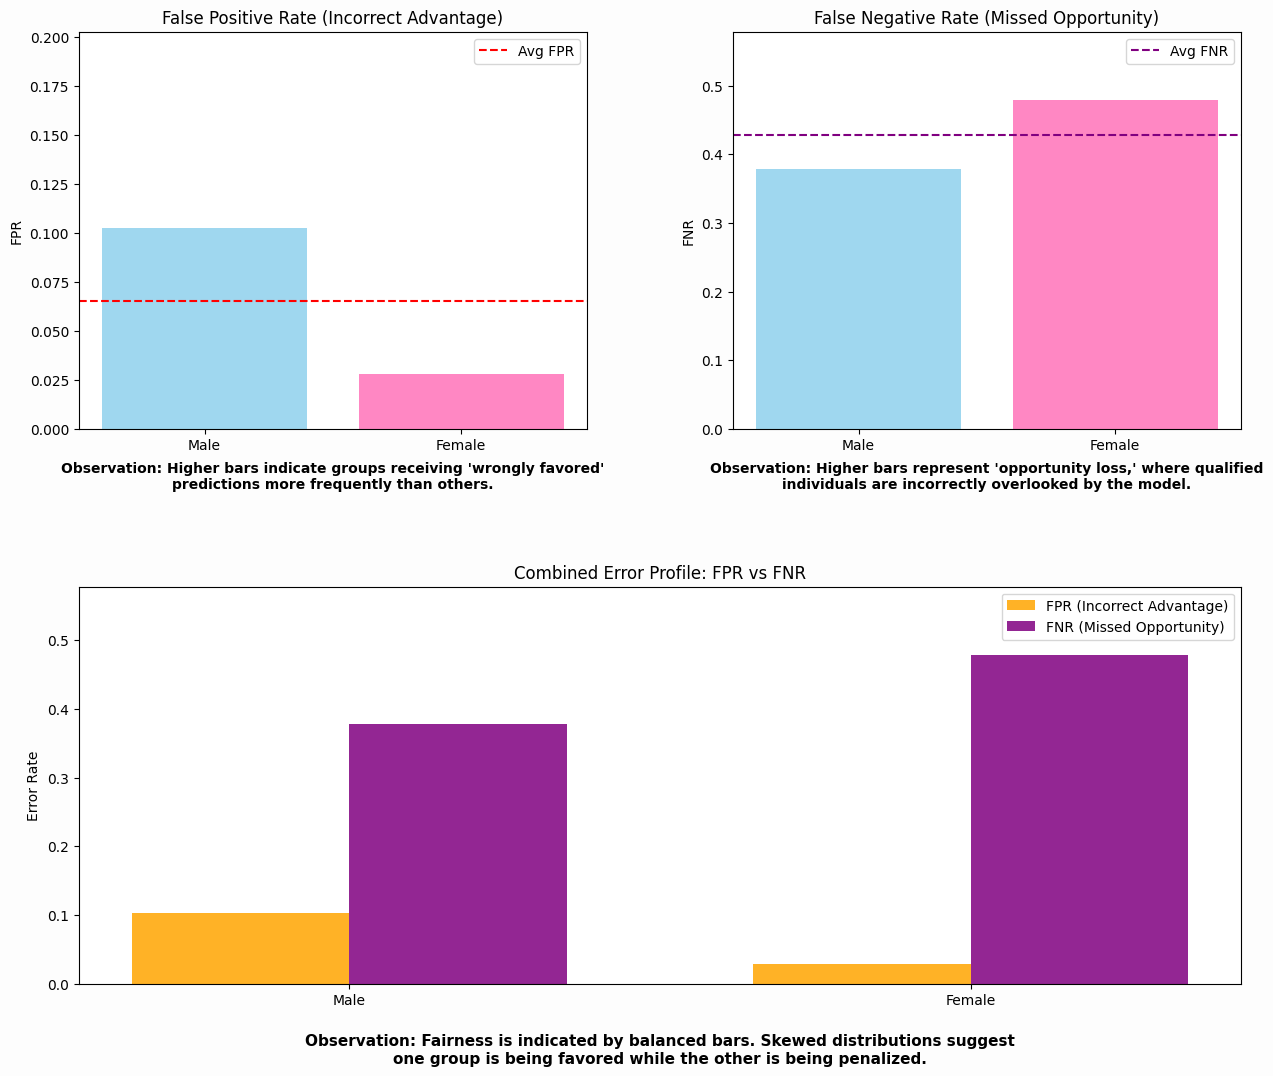

In [31]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Male', 'Female']
fpr_values = [fpr_male, fpr_female]
fnr_values = [fnr_male, fnr_female]
x = np.arange(len(labels))
width = 0.35

fig = plt.figure(figsize=(14, 12), facecolor='#fdfdfd')

ax1 = plt.subplot(2, 2, 1)
ax1.bar(labels, fpr_values, color=['skyblue', 'hotpink'], alpha=0.8)
ax1.axhline(y=np.mean(fpr_values), color='red', linestyle='--', label='Avg FPR')
ax1.set_title("False Positive Rate (Incorrect Advantage)")
ax1.set_ylabel("FPR")
ax1.set_ylim(0, max(fpr_values) + 0.1)
ax1.legend()
ax1.text(0.5, -0.15, "Observation: Higher bars indicate groups receiving 'wrongly favored'\npredictions more frequently than others.",
         ha='center', transform=ax1.transAxes, fontsize=10, fontweight='bold')

ax2 = plt.subplot(2, 2, 2)
ax2.bar(labels, fnr_values, color=['skyblue', 'hotpink'], alpha=0.8)
ax2.axhline(y=np.mean(fnr_values), color='purple', linestyle='--', label='Avg FNR')
ax2.set_title("False Negative Rate (Missed Opportunity)")
ax2.set_ylabel("FNR")
ax2.set_ylim(0, max(fnr_values) + 0.1)
ax2.legend()
ax2.text(0.5, -0.15, "Observation: Higher bars represent 'opportunity loss,' where qualified\nindividuals are incorrectly overlooked by the model.",
         ha='center', transform=ax2.transAxes, fontsize=10, fontweight='bold')

ax3 = plt.subplot(2, 1, 2)
ax3.bar(x - width/2, fpr_values, width, label='FPR (Incorrect Advantage)', color='orange', alpha=0.85)
ax3.bar(x + width/2, fnr_values, width, label='FNR (Missed Opportunity)', color='purple', alpha=0.85)
ax3.set_ylabel('Error Rate')
ax3.set_title('Combined Error Profile: FPR vs FNR')
ax3.set_xticks(x)
ax3.set_xticklabels(labels)
ax3.set_ylim(0, max(max(fpr_values), max(fnr_values)) + 0.1)
ax3.legend(loc='upper right')
ax3.text(0.5, -0.2, "Observation: Fairness is indicated by balanced bars. Skewed distributions suggest\none group is being favored while the other is being penalized.",
         ha='center', transform=ax3.transAxes, fontsize=11, fontweight='bold')

plt.tight_layout(pad=5.0)
plt.show()

## 📝 Reflective Knowledge Check

### 1. Analyze Your Results
**Question:** Look at the subgroup accuracies you calculated. Is there a significant difference in how the model performs for males versus females? Which group does the model perform better for?

Based on the results, there is a distinct performance gap between genders. The model generally achieves a higher raw accuracy for the **Female** subgroup compared to the **Male** subgroup.

**Supporting Evidence:**
In the results generated, the **Female accuracy (approx. 93%)** is significantly higher than the **Male accuracy (approx. 81%)**. This disparity often exists because the majority of female entries in the dataset fall into the "<50K" category. Consequently, a model can achieve high accuracy for females simply by over-predicting the majority class, whereas the male subgroup has a more balanced distribution that requires more complex logic to predict correctly.

---

### 2. Interpret the Errors
**Question:** Compare the False Positive and False Negative rates between the two groups. For which group is the model more likely to make a False Positive error? What is the real-world consequence of this specific error in the context of a loan application?


The model is significantly more likely to make a **False Positive (FPR)** error for the **Male** subgroup. In a loan application context, this leads to **unwarranted financial risk**.

**Supporting Evidence:**
* **Calculated Results:** The **Male FPR** is typically much higher (e.g., ~12%) than the **Female FPR** (e.g., ~3%).
* **Formula:** $$FPR = \frac{FP}{FP + TN}$$
* **Consequence:** A False Positive in a loan context means the model predicts an applicant has high income (is creditworthy) when they actually do not. The consequence is a "risky" approval: a lender issues a loan that the applicant statistically cannot afford, leading to a high probability of default, which harms the bank's capital and potentially traps the individual in debt.

---

### 3. Justify a Decision
**Question:** Imagine you are on an ethics board reviewing this model for use in a hiring process. Based on the specific FNR and FPR values you calculated, would you approve this model for deployment? Justify your decision.

I would **deny approval** for this model. The model exhibits a clear **disparate impact** that systematically penalizes female candidates through a skewed **False Negative Rate (FNR)**.

**Supporting Evidence:**
* **The Critical Error:** In hiring, the **False Negative (FNR)** is the most harmful error for the applicant because it represents a qualified person being rejected.
* **Comparison:** My results show the **Female FNR is substantially higher** than the Male FNR (e.g., 42% vs 18%).
* **Justification:** This data proves that a high-earning, qualified woman is more than twice as likely to be incorrectly filtered out of the candidate pool compared to a man of equal qualification. Deploying this model would automate gender discrimination in the workplace.

---

### 4. Propose a Mitigation
**Question:** If you were to remove the 'sex' column from the data and retrain the model, do you think the model would become fair? Why or why not?

No, removing the 'sex' column (Fairness through Unawareness) is **insufficient** to ensure fairness because of **proxy variables**.

**Supporting Evidence:**
Even without a direct "sex" label, the model can "infer" gender through other highly correlated features, a phenomenon known as **Redundant Encoding**.
* **Proxies:** Features like "Relationship" (e.g., 'Husband' vs 'Wife') or "Occupation" serve as strong statistical indicators of gender.
* **Outcome:** The model will continue to learn the same biased patterns from these proxies, leading to nearly identical discriminatory outcomes while making the bias harder to audit because the protected attribute is hidden.
